# Response Time Analysis (RTA)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.ensemble import IsolationForest

## 1. Importing datasets

In [2]:
url2 = 'https://raw.githubusercontent.com/JeroenGuillierme/Project-MDA/main/Data/'

rta_df = pd.read_csv(
    f'{url2}total_df_with_distances.csv')

## 2. Outlier Detection for Response Time T3-T0

IsolationForest (for outliers/anomalies of the response time T3-T0, because some are longer than 1 day)
=> probably incorrectly filled in, in the dataset

In [3]:
interventions_data = rta_df[rta_df['Intervention'] == 1]
print(interventions_data['T3-T0'].isna().sum())

1965


[Text(0.5, 1.0, 'Logscale of Response Times'), Text(0.5, 0, 'Log(T3-T0)')]

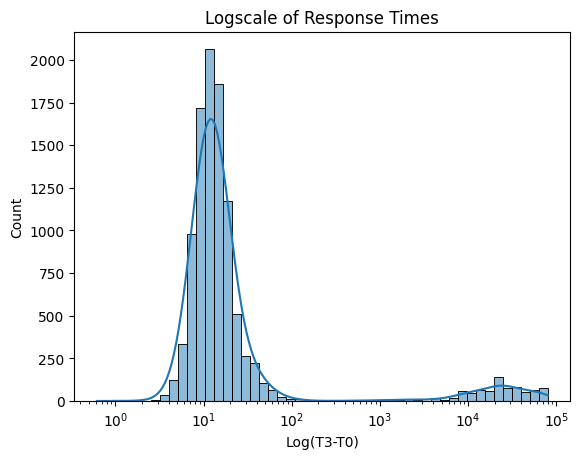

In [16]:
# Plot response times
sns.histplot(data=interventions_data['T3-T0'], bins=50, log_scale=True, kde=True).set(title='Logscale of Response Times', xlabel='Log(T3-T0)') 
# Right-skewed distribution, so log scale was used.

In [8]:
# Split the DataFrame into two: one with the NaN and one without in the 'T3-T0' column
# DataFrame with NaN values
interventions_data_with_nan = interventions_data[interventions_data['T3-T0'].isna()]  
# DataFrame without NaN values
interventions_data_without_nan = interventions_data[~interventions_data['T3-T0'].isna()]  

print('Without NaN: ', len(interventions_data_without_nan))
print('With NaN: ', len(interventions_data_with_nan))

Without NaN:  10343
With NaN:  1965


In [11]:
Time = interventions_data_without_nan['T3-T0']

# IsolationForest algorithm
IsoFo = IsolationForest(n_estimators=100, contamination='auto',
                        random_state=45)  # Random state added for reproducibility
y_labels = IsoFo.fit_predict(np.array(Time).reshape(-1, 1))

# Only including the inliers
interventions_data_filtered = interventions_data_without_nan[y_labels == 1]  # DataFrame with inliers
discarded_rows = interventions_data_without_nan[y_labels == -1]  # DataFrame with outliers

min_timedelta = discarded_rows['T3-T0'].min()  # Time deltas larger than 44.27 minutes are discarded
max_timedelta = discarded_rows['T3-T0'].max()
min_timedelta2 = interventions_data_filtered['T3-T0'].min()
max_timedelta2 = interventions_data_filtered['T3-T0'].max()
print(f"min response time of outliers: {min_timedelta}") 
print(f"max response time of outliers: {max_timedelta}")
print(f"min response time of inliers: {min_timedelta2}") 
print(f"max response time of inliers: {max_timedelta2}")
print(f"Number of discarded rows: {len(discarded_rows)}")
print(f"Number of filtered rows: {len(interventions_data_filtered)}")


min response time of outliers: 43.78635
max response time of outliers: 80267.83333333333
min response time of inliers: 0.6166666666666667
max response time of inliers: 43.56666666666667
Number of discarded rows: 1047
Number of filtered rows: 9296


In [12]:
print("\nFiltered DataFrame (Inliers):")
interventions_data_filtered.head(5)


Filtered DataFrame (Inliers):


,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,AED,Ambulance,Mug,PIT,Province,distance_to_aed,distance_to_ambulance,distance_to_mug,distance_to_pit
0,51.20685,5.13662,1,1.0,18.884917,P003 - Cardiac arrest,MUG,0,0,0,0,Antwerpen,1.239539,3.523140,8.380098,2.792722
1,51.24848,4.43869,1,1.0,4.238700,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.335321,1.454942,1.259929,2.493499
2,51.24848,4.43869,1,1.0,12.612550,P003 - Cardiac arrest,MUG,0,0,0,0,Antwerpen,0.335321,1.454942,1.259929,2.493499
3,51.28273,4.42134,1,1.0,13.427900,P003 - Cardiac arrest,MUG,0,0,0,0,Antwerpen,0.083377,3.262920,3.434839,5.712662
4,51.28273,4.42134,1,1.0,36.619500,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.083377,3.262920,3.434839,5.712662


**Total dataset without outliers**

In [13]:
# Add rows with NaN values again:
rta_ready = pd.concat([interventions_data_filtered, interventions_data_with_nan], axis=0)

[Text(0.5, 1.0, 'Logscale of Response Times'), Text(0.5, 0, 'Log(T3-T0)')]

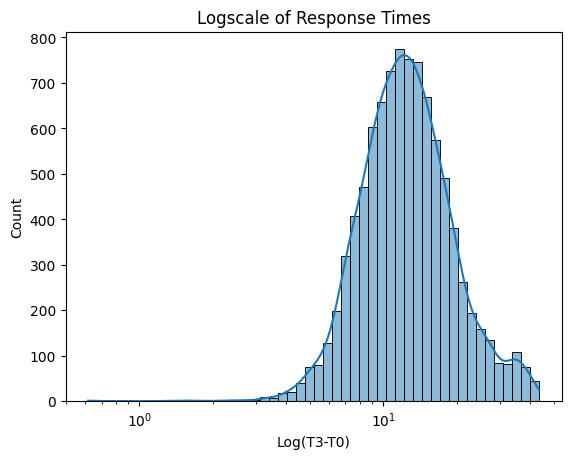

In [14]:
# Plot response times
sns.histplot(data=rta_ready['T3-T0'], bins=50, log_scale=True, kde=True).set(title='Logscale of Response Times', xlabel='Log(T3-T0)') 
# Right-skewed distribution, so log scale was used.

In [15]:
# Last check if no weird values are included in the dataset

# Get the minimum and maximum values of the 'latitude' column
min_latitude = rta_ready['Latitude'].min()
max_latitude = rta_ready['Latitude'].max()
# Get the minimum and maximum values of the 'longitude' column
min_longitude = rta_ready['Longitude'].min()
max_longitude = rta_ready['Longitude'].max()
# Get the minimum and maximum values of the response time column
min_timedelta = rta_ready['T3-T0'].min()
max_timedelta = rta_ready['T3-T0'].max()

print('Length of dataset: ', len(rta_ready))
print('Number of missing values per column: \n', print(rta_ready[['Latitude', 'Longitude', 'Intervention',
                                                                  'Eventlevel', 'T3-T0', 'EventType', 'AED', 
                                                                  'Ambulance', 'Mug']].isna().sum()))  # 1210 missing values for latitude from intervention dataset
print(f"Minimum latitude of dataset: {min_latitude}")
print(f"Maximum latitude of dataset: {max_latitude}")
print(f"Minimum longitude of dataset: {min_longitude}")
print(f"Maximum longitude of dataset: {max_longitude}")
print(f"min_timedelta of dataset: {min_timedelta}")  # Minimum outlier value = 44.27 minutes
print(f"max_timedelta of dataset: {max_timedelta}")  # Maximum outlier value = 80267.83 minutes

Length of dataset:  11261
Latitude           0
Longitude          0
Intervention       0
Eventlevel         0
T3-T0           1965
EventType          0
AED                0
Ambulance          0
Mug                0
dtype: int64
Number of missing values per column: 
 None
Minimum latitude of dataset: 49.5114
Maximum latitude of dataset: 51.48203
Minimum longitude of dataset: 2.58552
Maximum longitude of dataset: 6.21838
min_timedelta of dataset: 0.6166666666666667
max_timedelta of dataset: 43.56666666666667
